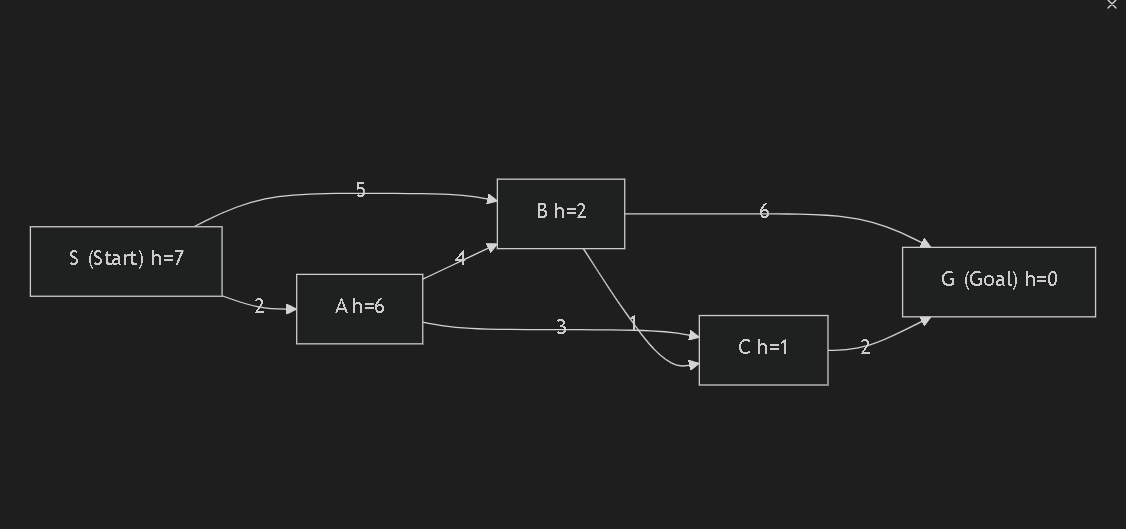



In [1]:
# Import the heapq module, which provides an implementation of the heap queue algorithm, also known as the priority queue algorithm.
import heapq

# Define the heuristic values for each node in the graph, representing the estimated cost from the node to the goal.
heuristics = {
    'S': 7,
    'A': 6,
    'B': 2,
    'C': 1,
    'G': 0
}

# Define the graph using an adjacency list where each key is a node and its value is a dictionary of neighboring nodes and their edge weights.
graph = {
    'S': {'A': 2, 'B': 5},
    'A': {'B': 4, 'C': 3},
    'B': {'C': 1, 'G': 6},
    'C': {'G': 2},
    'G': {}
}

# Define a function for the A* search algorithm that takes the graph, heuristics, start node, and goal node as arguments.
def astar_search(graph, heuristics, start, goal):
    # Initialize an open list as a priority queue to store nodes to be explored, storing tuples of (f_cost, current_node, path).
    open_list = []

    # Push the start node onto the open list with an initial f_cost equal to its heuristic value, and a path containing only itself.
    heapq.heappush(open_list, (heuristics[start], start, [start]))

    # Initialize a dictionary to keep track of the lowest known actual cost (g_cost) from the start node to each explored node.
    g_costs = {start: 0}

    # Start a loop that will continue as long as there are nodes in the open list waiting to be explored.
    while open_list:
        # Pop the node with the lowest f_cost from the priority queue.
        current_f_cost, current_node, current_path = heapq.heappop(open_list)

        # Check if the current node we just popped is our goal node.
        if current_node == goal:
            # If the goal is reached, return the complete path and the total actual cost (g_cost) to get there.
            return current_path, g_costs[current_node]

        # Iterate over all neighboring nodes of the current node to explore paths further.
        for neighbor, weight in graph[current_node].items():
            # Calculate the tentative g_cost to reach the neighbor by adding the edge weight to the current node's g_cost.
            tentative_g_cost = g_costs[current_node] + weight

            # Check if we have not visited this neighbor yet, or if this new path to the neighbor is cheaper than any previously found path.
            if neighbor not in g_costs or tentative_g_cost < g_costs[neighbor]:
                # Update the g_cost for this neighbor with the newly found cheaper cost.
                g_costs[neighbor] = tentative_g_cost

                # Calculate the f_cost for the neighbor, which is the sum of its actual g_cost and its estimated heuristic cost to the goal.
                f_cost = tentative_g_cost + heuristics[neighbor]

                # Create a new path to the neighbor by appending the neighbor to the current path we took to get here.
                new_path = current_path + [neighbor]

                # Push the neighbor onto the open list with its calculated f_cost, node name, and the updated path.
                heapq.heappush(open_list, (f_cost, neighbor, new_path))

    # If the open list becomes empty and the goal was never reached, return None to indicate no valid path exists.
    return None, None

# Call the astar_search function to execute the algorithm with our defined graph, heuristics, start node 'S', and goal node 'G'.
path, total_cost = astar_search(graph, heuristics, 'S', 'G')

# Print the final result, joining the path list with arrows to show the optimal path taken.
print(f"Optimal Path: {' -> '.join(path)}")

# Print the total actual cost incurred by traversing the optimal path.
print(f"Total Cost: {total_cost}")


Optimal Path: S -> A -> C -> G
Total Cost: 7
